In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [ ]:
c_guess_vals=[0.9791281505684851]
A_vals=[3.4342536609022134]

s1_middle = 25.5
s2_middle = 28.6

In [5]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

f_1 = qubit.frequency*1.2 #Ajotaajuudet
f_2 = qubit.frequency*1.4

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [6]:
def find_drive_frequency(A,f_supp,evolution,f_rabi,c_guess,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    c_vals=[]
    
    for i in range(min_range, max_range):
        f_1_shifted=f_1*(c_guess+i/scale)
        f_2_shifted=f_2*(c_guess+i/scale)

        c_vals.append(c_guess+i/scale)
        delta=qubit.frequency-2*f_1_shifted+f_2_shifted #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 3.3:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_supp,A,evolution,dim,f_rabi,t_ramp=10,U_f=15,f_2=f_2_shifted,K=200, drag=True)
        elif A < 3.8:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_supp,A,evolution,dim,f_rabi,t_ramp=10,U_f=10,f_2=f_2_shifted,K=200, drag=True)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_supp,A,evolution,dim,f_rabi,t_ramp=10,U_f=1,f_2=f_2_shifted,K=200, drag=True)
        
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_q-2ω_1+ω_2 (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    c=c_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(c,pi_pulse,[e_max,f_max],max_e_vals)

def find_params(f_1,f_2,A,evolution,f_rabi,lims,scales,verbose=True):

    #Rajat AC-stark siirtymälle
    min_range_s1 = lims[0][0]
    max_range_s1 = lims[0][1]

    min_range_s2 = lims[1][0]
    max_range_s2 = lims[1][1]
    
    e_data=[]
    f_data=[]

    s1_vals=np.arange(min_range_s1,max_range_s1)/scales[0] + s1_middle
    s2_vals=np.arange(min_range_s2,max_range_s2)/scales[1] + s2_middle
    
    for i in range(min_range_s1,max_range_s1):
        s1 = i/scales[0] + s1_middle
        
        max_e_vals=[]
        max_f_vals=[]
        
        for j in range(min_range_s2,max_range_s2):

            s2 = j/scales[1] + s2_middle
    
            sim_vals = pulses.sim_3_part_pulses(f_1,[s1,s2],A,evolution,dim,f_rabi,t_ramp=10,U_f=1,f_2=f_2,K=200,drag=True)

            max_e_vals.append(sim_vals[0])
            max_f_vals.append(sim_vals[1])

        e_data.append(max_e_vals)
        f_data.append(max_f_vals)

    xtick_locs=np.arange(0,1, step=0.2)*len(s1_vals)
    ytick_locs=np.arange(0,1, step=0.2)*len(s2_vals)

    xlabels=[round(s1_vals[int(i)],3) for i in xtick_locs]
    ylabels=[round(s2_vals[int(i)],3) for i in ytick_locs]

    plt.figure(figsize=(6, 6))
    plt.imshow(np.array(e_data).T, origin='lower', cmap='inferno', norm=LogNorm(), aspect='auto')    
    plt.xlabel("ω_s1")
    plt.xticks(xtick_locs,xlabels)
    plt.ylabel("ω_s2")
    plt.yticks(ytick_locs,ylabels)
    plt.colorbar(label="e-tason suurin todennäköisyys")
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(np.array(f_data).T, origin='lower', cmap='inferno', norm=LogNorm(), aspect='auto')    
    plt.xlabel("ω_s1")
    plt.xticks(xtick_locs,xlabels)
    plt.ylabel("ω_s2")
    plt.yticks(ytick_locs,ylabels)
    plt.colorbar(label="f-tason suurin todennäköisyys")
    plt.show()

    if verbose:
        print(e_data)
        print(f_data)

    min_index = np.unravel_index(np.argmin(f_data), np.array(f_data).shape)
    
    s1=s1_vals[min_index[0]]
    s2=s2_vals[min_index[1]]
    
    return(s1,s2)

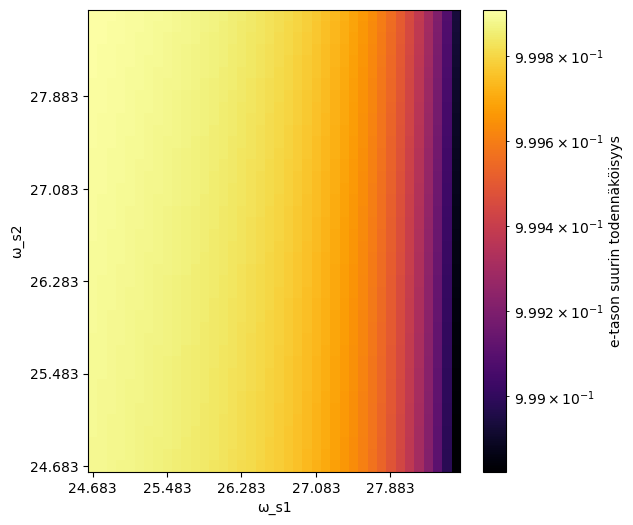

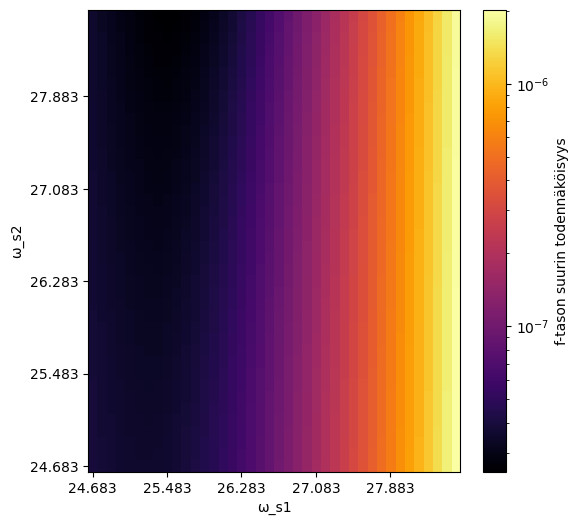

[[np.float64(0.9998876489598828), np.float64(0.9998880486416787), np.float64(0.9998884547650018), np.float64(0.9998888674781088), np.float64(0.99988928693342), np.float64(0.9998897132877199), np.float64(0.9998901467021272), np.float64(0.9998905873423165), np.float64(0.9998910353783672), np.float64(0.9998914909853402), np.float64(0.9998919543429726), np.float64(0.9998924256361539), np.float64(0.9998929050546259), np.float64(0.9998933927934996), np.float64(0.9998938890531841), np.float64(0.9998943940392441), np.float64(0.9998949079630518), np.float64(0.9998954310413047), np.float64(0.9998959634966335), np.float64(0.9998965055569523), np.float64(0.9998970574563477), np.float64(0.9998976194344208), np.float64(0.9998981917366169), np.float64(0.9998987746141219), np.float64(0.9998993683238462), np.float64(0.9998999731282493), np.float64(0.9999005892953227), np.float64(0.9999012170982732), np.float64(0.9999018568151862), np.float64(0.9999025087290511), np.float64(0.9999031731271959), np.float

Amplitudi (GHz): 3.4342536609022134
Ensimmäinen hiljennetty taajuus (10⁹ rad/s): 25.482871907348912
Toinen hiljennetty taajuus (10⁹ rad/s): 28.58287190734891
E-tason suurin todennäköisyys: 0.9998896043112782
F-tason suurin todennäköisyys: 2.511644434769998e-08


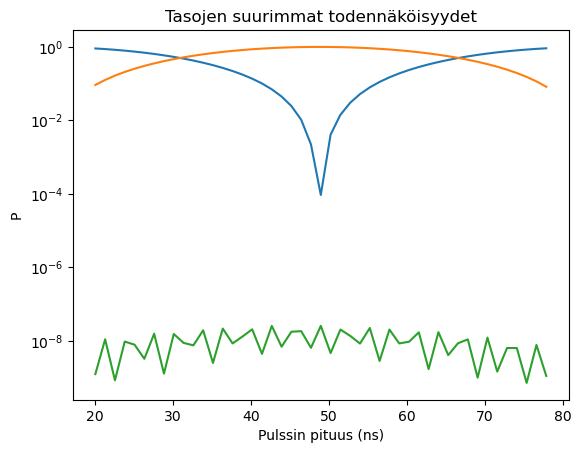

---------------------------------------------


In [7]:
A=A_vals[0]
f_rabi=2*np.pi/60

s1_vals=[]
s2_vals=[]

params=find_params(f_1*c_guess_vals[0],f_2*c_guess_vals[0],A,evolution_eigenbasis,f_rabi,[[-20,20],[-20,20]],[10,10])
s1_vals.append(params[0])
s2_vals.append(params[1])

m=1

vals = pulses.sim_3_part_pulses(f_1*c_guess_vals[0],[s1_vals[-1],s2_vals[-1]],A,evolution_eigenbasis,dim,f_rabi/m,f_2=f_2*c_guess_vals[0],t_ramp=10,U_f=1,K=200,drag=True)

print("Amplitudi (GHz):", A)

print("Ensimmäinen hiljennetty taajuus (10⁹ rad/s):", s1_vals[-1])
print("Toinen hiljennetty taajuus (10⁹ rad/s):", s2_vals[-1])

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")

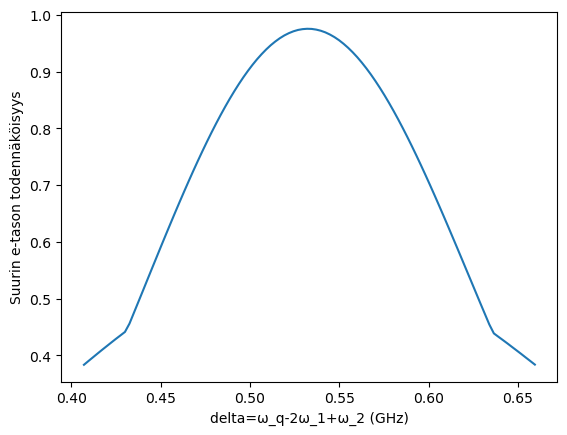

Amplitudi (GHz): 3.4342536609022134
AC-stark siirtymä (GHz): 0.5319942504214702
E-tason suurin todennäköisyys: 0.9998896043112782
F-tason suurin todennäköisyys: 2.511644434769998e-08
Pulssin pituus (ns): 45.176440339688256


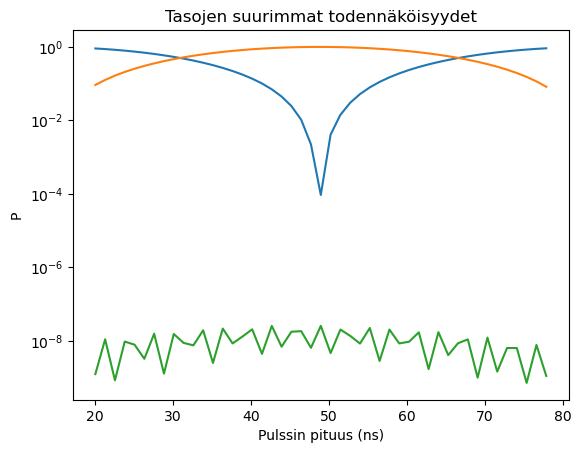

---------------------------------------------


In [8]:
params=find_drive_frequency(A,[s1_vals[-1],s2_vals[-1]],evolution_eigenbasis,f_rabi,c_guess_vals[0],[-50,50],10000)

c_opt = params[0] #Löydetty optimaalinen ajotaajuus

m=1
vals = pulses.sim_3_part_pulses(f_1*c_opt,[s1_vals[-1],s2_vals[-1]],A,evolution_eigenbasis,dim,f_rabi/m,f_2=f_2*c_opt,t_ramp=10,U_f=1,K=200,drag=True)

print("Amplitudi (GHz):", A)
print("AC-stark siirtymä (GHz):", 2*f_1*(1-c_opt)-f_2*(1-c_opt))

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])
print("Pulssin pituus (ns):", params[1])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")

## Verrokkipulssi ilman dragia

Amplitudi (GHz): 3.4342536609022134
E-tason suurin todennäköisyys: 0.9999338741332018
F-tason suurin todennäköisyys: 3.335675740649336e-07
Pulssin pituus (ns): 48.9529063906415


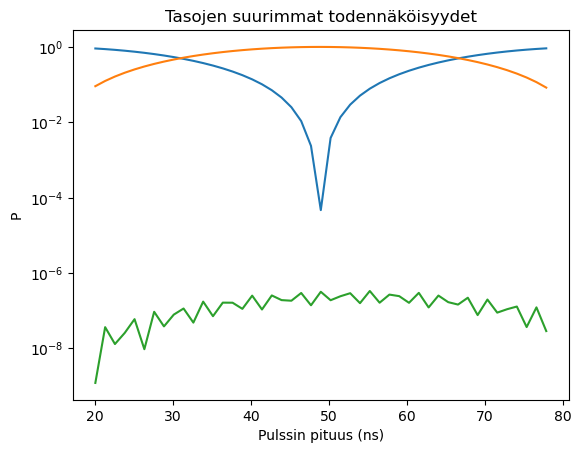

---------------------------------------------


In [9]:
m=1

vals = pulses.sim_3_part_pulses(f_1*c_guess_vals[0],[s1_vals[-1],s2_vals[-1]],A,evolution_eigenbasis,dim,f_rabi/m,f_2=f_2*c_guess_vals[0],t_ramp=10,U_f=1,K=200,drag=False)

print("Amplitudi (GHz):", A)
print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])
print("Pulssin pituus (ns):", vals[2])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")